# 5. Кластеризація k-Medians

**k-Medians** — варіант k-Means з медіаною замість середнього. Стійкіший до викидів.

Мінімізує суму манхеттенських відстаней (L1) замість евклідових (L2).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time
from pyclustering.cluster.kmedians import kmedians
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_processed.csv')
with open('top4_pairs.json') as f:
    pairs = json.load(f)

# Підвибірка для pyclustering
np.random.seed(42)
idx_s = np.random.choice(len(df), min(8000, len(df)), replace=False)
df_s = df.iloc[idx_s].reset_index(drop=True)
print(f"Вибірка: {df_s.shape}, Пари: {pairs}")

Вибірка: (8000, 5), Пари: [['education-num', 'occupation'], ['hours-per-week', 'occupation'], ['age', 'hours-per-week']]


In [2]:
def run_kmedians(X_list, k):
    np.random.seed(42)
    init = [X_list[i] for i in np.random.choice(len(X_list), k, replace=False)]
    kmed = kmedians(X_list, init)
    kmed.process()
    clusters = kmed.get_clusters()
    labels = np.zeros(len(X_list), dtype=int)
    for i, cl in enumerate(clusters):
        for idx in cl:
            labels[idx] = i
    return labels, kmed

## 5.1 Підбір k

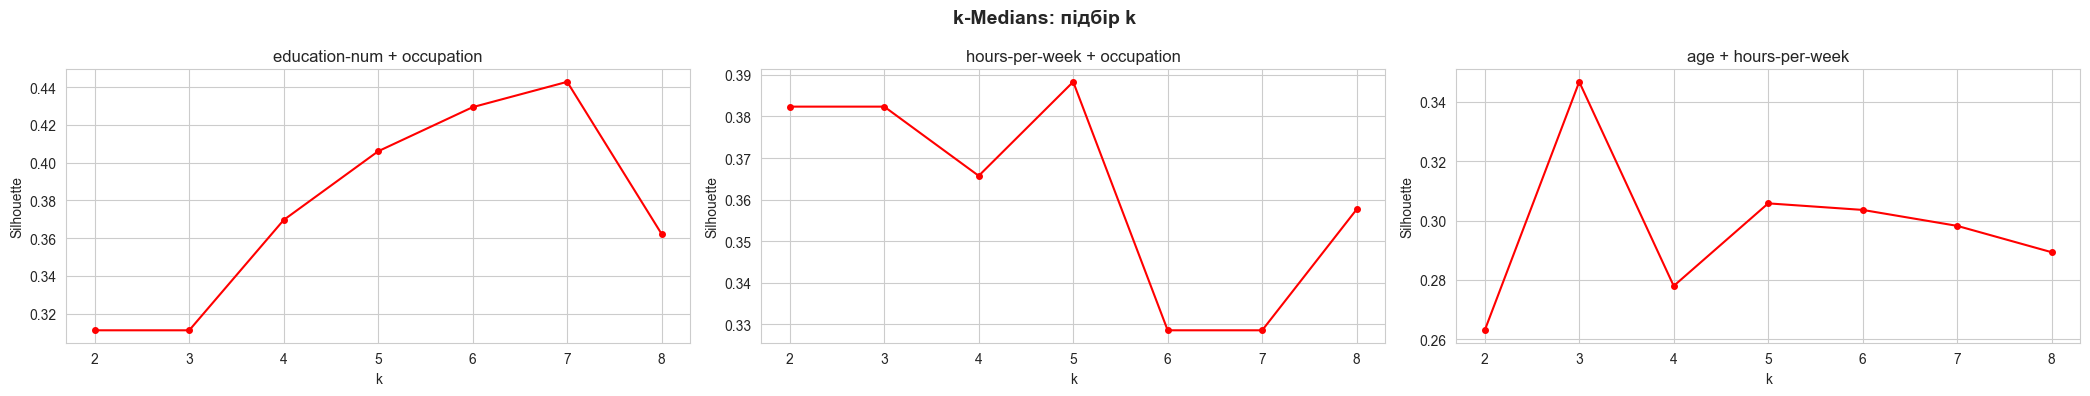

education-num + occupation: k = 7
hours-per-week + occupation: k = 5
age + hours-per-week: k = 3


In [3]:
K_range = range(2, 9)
best_k = {}
N = len(pairs)

fig, axes = plt.subplots(1, N, figsize=(7*N, 4))
for j, pair in enumerate(pairs):
    X = StandardScaler().fit_transform(df_s[pair].values)
    sils = []
    for k in K_range:
        labels, _ = run_kmedians(X.tolist(), k)
        sils.append(silhouette_score(X, labels))
    axes[j].plot(list(K_range), sils, 'ro-', markersize=4)
    axes[j].set_title(f'{pair[0]} + {pair[1]}')
    axes[j].set_xlabel('k'); axes[j].set_ylabel('Silhouette')
    best_k[j] = list(K_range)[np.argmax(sils)]

plt.suptitle('k-Medians: підбір k', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
for j, pair in enumerate(pairs):
    print(f"{pair[0]} + {pair[1]}: k = {best_k[j]}")

## 5.2 Кластеризація та 2D-візуалізація

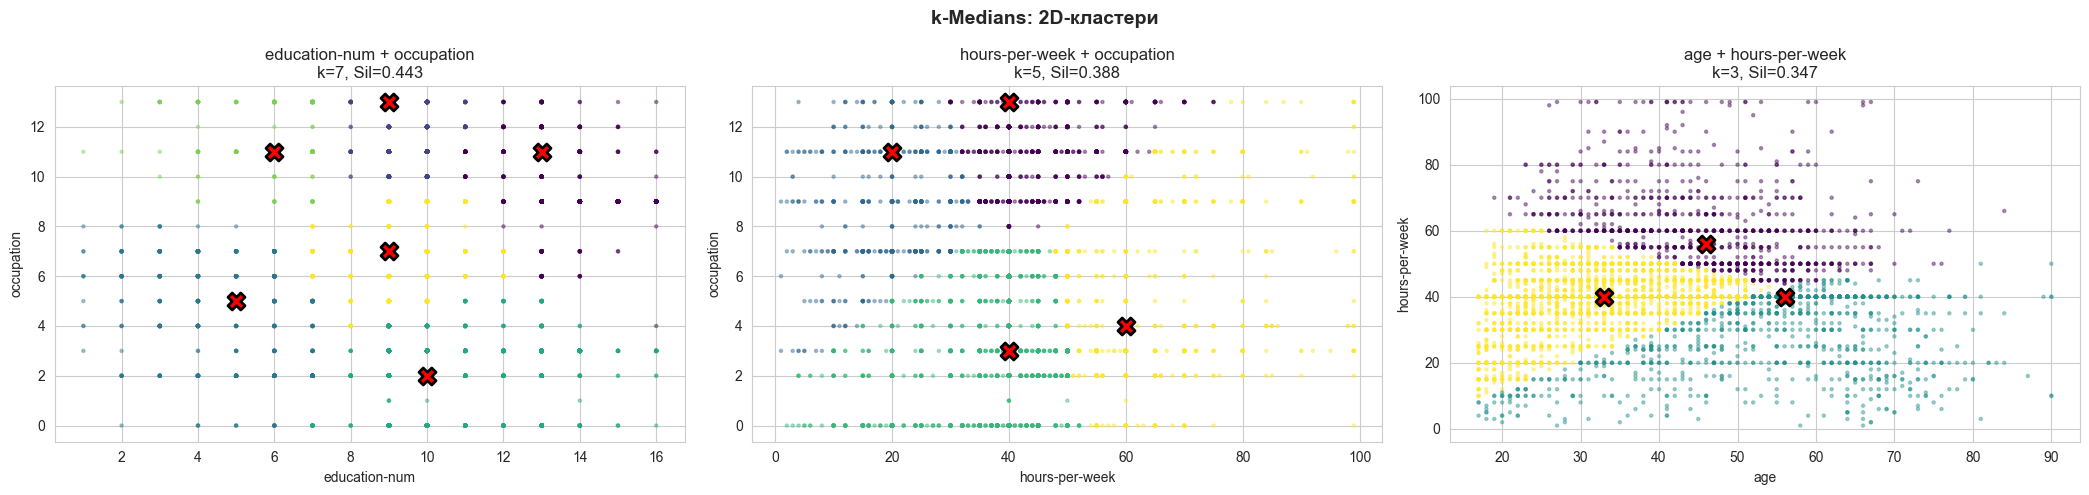

,algorithm,pair,k,silhouette,davies_bouldin,calinski_harabasz,time
0,k-Medians,education-num + occupation,7,0.442862,0.710087,6737.398581,0.116214
1,k-Medians,hours-per-week + occupation,5,0.388312,0.880754,5103.161956,0.124949
2,k-Medians,age + hours-per-week,3,0.346788,1.061714,3682.313455,0.146660


In [4]:
all_results = []
fig, axes = plt.subplots(1, N, figsize=(7*N, 5))

for j, pair in enumerate(pairs):
    X_raw = df_s[pair].values
    scaler = StandardScaler().fit(X_raw)
    X = scaler.transform(X_raw)
    k = best_k[j]
    
    start = time.time()
    labels, kmed = run_kmedians(X.tolist(), k)
    elapsed = time.time() - start
    
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    all_results.append({'algorithm': 'k-Medians', 'pair': f'{pair[0]} + {pair[1]}',
                        'k': int(k), 'silhouette': sil, 'davies_bouldin': db,
                        'calinski_harabasz': ch, 'time': elapsed})
    
    idx = np.random.RandomState(42).choice(len(X_raw), min(5000, len(X_raw)), replace=False)
    axes[j].scatter(X_raw[idx, 0], X_raw[idx, 1], c=labels[idx], cmap='viridis', alpha=0.4, s=5)
    centers = scaler.inverse_transform(np.array(kmed.get_medians()))
    axes[j].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=150,
                    edgecolors='black', linewidths=2, zorder=5)
    axes[j].set_xlabel(pair[0]); axes[j].set_ylabel(pair[1])
    axes[j].set_title(f'{pair[0]} + {pair[1]}\nk={k}, Sil={sil:.3f}')

plt.suptitle('k-Medians: 2D-кластери', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(all_results)
results_df.to_csv('results_kmedians.csv', index=False)
results_df